# Análisis de la red de comunicaciones del 23F
## Estructura organizativa y facciones operativas en los documentos desclasificados

**TFM — Máster en Big Data**

Este notebook usa el **dataset_23f_master.csv** (versión enriquecida) que incluye:

- `entidades`: JSON con personas canónicas y conteos por documento
- `fase`: 6 etapas temporales (`1_pre_golpe` → `6_post_sentencia`)
- `ministerio` y `seccion`: procedencia institucional
- `clasificacion`: nivel de secreto

### Pregunta de investigación

¿Qué estructura organizativa revelan las comunicaciones del 23F y qué facciones
operativas pueden identificarse a partir del corpus desclasificado?

### Pipeline

1. Carga del corpus enriquecido
2. Construcción de dos grafos comparables (co-aparición + interacciones dirigidas)
3. Estructura global de cada red
4. **Detección de comunidades con resolución ajustable** (núcleo del análisis)
5. Patrones de interacción
6. Análisis temporal — visión global por fase (estadísticas resumen y persistencia)
7. Análisis institucional por ministerio
8. **Centralidad y clasificación de actores en Núcleo / Puentes / Periferia**
9. Validación externa contra la sentencia de 1982
10. Visualización
11. Exportación

## 0. Instalación de dependencias

Ejecuta esta celda **una sola vez**. Después reinicia el kernel.

In [1]:
%pip install pandas numpy networkx matplotlib seaborn python-louvain pyvis scipy

## 1. Configuración e imports

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import re
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# === LOCALIZACIÓN AUTOMÁTICA DEL DATASET ===
# Estrategia en 3 fases:
#   1) Búsqueda rápida en rutas habituales (instantánea)
#   2) Búsqueda exhaustiva en todo el sistema (puede tardar)
#   3) Selector gráfico como último recurso (requiere interacción)
import os
from pathlib import Path

DATASET_FILENAMES = ['Dataset_23f.csv', 'dataset_23f.csv', 'dataset_23f_master.csv']

def busqueda_rapida():
    """Fase 1: rutas habituales. Instantánea."""
    rutas = [
        Path.cwd(),
        Path.cwd().parent,
        Path.home() / 'Downloads',
        Path.home() / 'Descargas',
        Path.home() / 'Desktop',
        Path.home() / 'Escritorio',
        Path.home() / 'OneDrive' / 'Escritorio',
        Path.home() / 'OneDrive' / 'Desktop',
        Path.home() / 'Documents',
        Path.home() / 'Documentos',
    ]
    for ruta in rutas:
        if not ruta.exists():
            continue
        for nombre in DATASET_FILENAMES:
            candidato = ruta / nombre
            if candidato.is_file():
                return str(candidato)
    return None

def busqueda_exhaustiva():
    """Fase 2: recorre el sistema. Puede tardar 10-60 segundos.
    Limita la búsqueda al árbol del usuario y unidades comunes."""
    print('  Buscando en todo el sistema (puede tardar)...')
    raices = [Path.home()]
    # En Windows, añadir otras unidades si existen
    if os.name == 'nt':
        for letra in 'CDEFGHIJ':
            d = Path(f'{letra}:/')
            if d.exists():
                raices.append(d)
    # Carpetas a omitir para acelerar
    omit = {'node_modules', '.git', 'venv', '.venv', 'env', '__pycache__',
             'AppData', 'Library', '.cache', 'Trash', '$Recycle.Bin',
             'Windows', 'Program Files', 'Program Files (x86)', 'ProgramData'}
    for raiz in raices:
        if not raiz.exists():
            continue
        try:
            for dirpath, dirnames, filenames in os.walk(raiz):
                # Filtrar carpetas omitidas in-place
                dirnames[:] = [d for d in dirnames if d not in omit
                                and not d.startswith('.')]
                for nombre in DATASET_FILENAMES:
                    if nombre in filenames:
                        return str(Path(dirpath) / nombre)
        except (PermissionError, OSError):
            continue
    return None

def busqueda_grafica():
    """Fase 3: cuadro de diálogo gráfico. Requiere clic del usuario."""
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        path = filedialog.askopenfilename(
            title='Selecciona el archivo del dataset (CSV)',
            filetypes=[('CSV', '*.csv'), ('Todos', '*.*')]
        )
        root.destroy()
        return path if path else None
    except Exception as e:
        print(f'  No se pudo abrir el selector gráfico: {e}')
        return None

# Ejecutar las tres fases en orden
print('Localizando dataset...')
DATASET_PATH = busqueda_rapida()
if DATASET_PATH is None:
    print('  No encontrado en rutas habituales.')
    DATASET_PATH = busqueda_exhaustiva()
if DATASET_PATH is None:
    print('  No encontrado en búsqueda exhaustiva. Abriendo selector...')
    DATASET_PATH = busqueda_grafica()

if not DATASET_PATH:
    raise FileNotFoundError(
        '\n\n❌ No se pudo localizar el dataset.\n'
        f'   Nombres aceptados: {DATASET_FILENAMES}\n'
    )

print(f'✓ Dataset cargado desde: {DATASET_PATH}')

Localizando dataset...
✓ Dataset cargado desde: c:\Users\migue\Downloads\Dataset_23f.csv


## 2. Carga del corpus enriquecido

In [3]:
df = pd.read_csv(DATASET_PATH)
print(f'Total documentos: {len(df)}')

print(f'\n=== Distribución por fase ===')
print(df['fase'].value_counts().sort_index())

print(f'\n=== Distribución por ministerio ===')
print(df['ministerio'].value_counts())

print(f'\n=== Distribución por clasificación ===')
print(df['clasificacion'].value_counts())

Total documentos: 167

=== Distribución por fase ===
fase
1_pre_golpe          10
2_noche_golpe        22
3_dias_inmediatos    17
4_instruccion        48
5_juicio_oral        63
6_post_sentencia      7
Name: count, dtype: int64

=== Distribución por ministerio ===
ministerio
Defensa       108
Exteriores     31
Interior       27
Name: count, dtype: int64

=== Distribución por clasificación ===
clasificacion
sin_marca    141
RESERVADO     14
SECRETO       12
Name: count, dtype: int64


## 3. Parseo del campo `entidades`

In [4]:
def parse_entities(s):
    if pd.isna(s):
        return {}
    try:
        return json.loads(s)
    except (json.JSONDecodeError, TypeError):
        return {}

df['entidades_dict'] = df['entidades'].apply(parse_entities)

all_entities = Counter()
for d in df['entidades_dict']:
    for ent, count in d.items():
        all_entities[ent] += count

print(f'Entidades canónicas únicas en el corpus: {len(all_entities)}')
print(f'Total menciones: {sum(all_entities.values())}')
print(f'\nTop 20 entidades:')
for ent, count in all_entities.most_common(20):
    print(f'  {count:5d}  {ent}')

Entidades canónicas únicas en el corpus: 30
Total menciones: 6177

Top 20 entidades:
   1149  Antonio Tejero
    996  Alfonso Armada
    962  Congreso de los Diputados
    675  Jaime Milans del Bosch
    650  Guardia Civil
    348  Juan Carlos I
    259  José Luis Cortina
    184  Consejo Supremo de Justicia Militar
    142  CESID
    127  Luis Torres Rojas
    109  Juan García Carrés
     88  JUJEM
     68  Casa Real / Zarzuela
     51  Manuel Gutiérrez Mellado
     48  Felipe González
     48  Cafetería Galaxia
     48  AOME
     39  Leopoldo Calvo-Sotelo
     26  Alexander Haig
     25  Santiago Carrillo


In [5]:
# Heurística para distinguir personas de instituciones
INSTITUTIONAL_KEYWORDS = [
    'Congreso', 'Guardia Civil', 'CESID', 'JUJEM', 'Consejo Supremo',
    'AOME', 'Casa Real', 'Zarzuela', 'RTVE', 'Prado del Rey', 'Brunete',
    'Cafetería Galaxia', 'Capitanía', 'Fuerza Nueva'
]

def is_institution(name):
    return any(kw in name for kw in INSTITUTIONAL_KEYWORDS)

# Documentos en los que aparece cada entidad (para filtros posteriores)
docs_per_entity = defaultdict(int)
for _, row in df.iterrows():
    for ent in row['entidades_dict']:
        docs_per_entity[ent] += 1

print('Presencia de entidades en documentos:')
for ent, n in sorted(docs_per_entity.items(), key=lambda x: -x[1])[:20]:
    print(f'  {n:3d} docs  {ent}')

Presencia de entidades en documentos:
   84 docs  Congreso de los Diputados
   74 docs  Guardia Civil
   70 docs  Consejo Supremo de Justicia Militar
   69 docs  Alfonso Armada
   68 docs  Juan Carlos I
   66 docs  Antonio Tejero
   49 docs  Jaime Milans del Bosch
   40 docs  CESID
   39 docs  José Luis Cortina
   27 docs  JUJEM
   27 docs  Luis Torres Rojas
   26 docs  Casa Real / Zarzuela
   20 docs  Juan García Carrés
   17 docs  Felipe González
   15 docs  Manuel Gutiérrez Mellado
   15 docs  Cafetería Galaxia
   14 docs  Leopoldo Calvo-Sotelo
    9 docs  División Acorazada Brunete
    8 docs  Santiago Carrillo
    8 docs  RTVE / Prado del Rey


## 4. Construcción de la red de co-aparición

Dos entidades quedan conectadas si aparecen juntas en un mismo documento.

### Decisión metodológica

El análisis principal se realiza sobre la **subred de personas** (excluyendo
entidades institucionales como CESID, JUJEM, Casa Real, Consejo Supremo, etc.).
Esto responde a la pregunta de investigación, centrada en la **influencia personal**
y los **flujos de comunicación entre individuos** durante el 23F.

Las instituciones se reservan para el **análisis institucional complementario**
(sección 10), donde se tratan como entidades de pertenencia, no como nodos de
la red principal.

Adicionalmente, filtramos actores con presencia documental muy baja
(menos de 3 documentos) para evitar **falsos puentes** derivados de la
estructura del corpus —p. ej., Carmen Díez aparece en pocos documentos pero
formalmente actúa como puente porque conecta una transcripción aislada con
el resto del corpus, sin reflejar un papel histórico real.

In [6]:
def build_coappearance_graph(df_subset, include_institutions=True, min_weight=1):
    G = nx.Graph()
    edge_weights = Counter()
    node_freq = Counter()
    node_docs = defaultdict(int)
    
    for _, row in df_subset.iterrows():
        ents = row['entidades_dict']
        if not include_institutions:
            ents = {e: c for e, c in ents.items() if not is_institution(e)}
        names = list(ents.keys())
        for n in names:
            node_freq[n] += ents[n]
            node_docs[n] += 1
        for a, b in combinations(sorted(names), 2):
            edge_weights[(a, b)] += 1
    
    for (a, b), w in edge_weights.items():
        if w >= min_weight:
            G.add_edge(a, b, weight=w)
    
    for n in G.nodes():
        G.nodes[n]['n_menciones'] = node_freq[n]
        G.nodes[n]['n_docs'] = node_docs[n]
        G.nodes[n]['es_institucion'] = is_institution(n)
    
    return G

G_coap = build_coappearance_graph(df)
G_coap_pers_full = build_coappearance_graph(df, include_institutions=False)

# Filtrar actores con poca presencia documental (evitar falsos puentes
# como Carmen Díez que solo aparece en una transcripción)
MIN_DOCS = 3
nodos_relevantes = [n for n in G_coap_pers_full.nodes()
                     if G_coap_pers_full.nodes[n].get('n_docs', 0) >= MIN_DOCS]
G_coap_pers = G_coap_pers_full.subgraph(nodos_relevantes).copy()

# Este es el grafo PRINCIPAL del análisis
G_main = G_coap_pers

print('Estructura de las redes:')
print(f'  Red completa (personas + instituciones, sin filtrar): {G_coap.number_of_nodes()} nodos, {G_coap.number_of_edges()} aristas')
print(f'  Red solo personas (sin filtrar):                       {G_coap_pers_full.number_of_nodes()} nodos, {G_coap_pers_full.number_of_edges()} aristas')
print(f'  Red principal (personas con ≥ {MIN_DOCS} docs):                  {G_main.number_of_nodes()} nodos, {G_main.number_of_edges()} aristas')

excluidos = set(G_coap_pers_full.nodes()) - set(G_main.nodes())
if excluidos:
    print(f'\nActores excluidos por baja presencia (< {MIN_DOCS} docs):')
    for n in sorted(excluidos):
        n_docs = G_coap_pers_full.nodes[n].get('n_docs', 0)
        print(f'  - {n}: {n_docs} documento(s)')

Estructura de las redes:
  Red completa (personas + instituciones, sin filtrar): 30 nodos, 358 aristas
  Red solo personas (sin filtrar):                       18 nodos, 120 aristas
  Red principal (personas con ≥ 3 docs):                  17 nodos, 109 aristas

Actores excluidos por baja presencia (< 3 docs):
  - Carmen Díez (esposa de Tejero): 1 documento(s)


## 5. Construcción de la red de interacciones dirigidas

Reutiliza la estrategia de turnos en transcripciones + verbos en prosa.

In [7]:
NAME_VARIANTS = {
    'Antonio Tejero': ['tejero', 'antonio tejero', 'teniente coronel tejero',
                        't', 't.', 'pedro'],
    'Jaime Milans del Bosch': ['milans del bosch', 'milans', 'jaime milans',
                                 'general milans'],
    'Alfonso Armada': ['armada', 'alfonso armada', 'general armada'],
    'Juan García Carrés': ['garcía carrés', 'garcia carres', 'g.c.', 'g c',
                             'gc', 'carrés', 'juan garcía carrés'],
    'Juan Carlos I': ['juan carlos', 'rey', 'su majestad', 'el rey',
                       'juan carlos i', 's.m.', 's m', 'j.c.', 'jc', 'monarca'],
    'José Luis Cortina': ['cortina', 'jose cortina', 'josé cortina',
                            'comandante cortina', 'jose luis cortina'],
    'Leopoldo Calvo-Sotelo': ['calvo sotelo', 'calvo-sotelo', 'leopoldo calvo'],
    'Adolfo Suárez': ['suarez', 'suárez', 'adolfo suárez', 'adolfo suarez'],
    'Santiago Carrillo': ['carrillo', 'santiago carrillo'],
    'Felipe González': ['felipe gonzález', 'felipe gonzalez', 'gonzález'],
    'Luis Torres Rojas': ['torres rojas', 'general torres rojas',
                            'luis torres rojas'],
    'Sabino Fernández Campo': ['sabino fernández', 'fernández campo',
                                 'sabino fernandez'],
    'Manuel Gutiérrez Mellado': ['gutiérrez mellado', 'gutierrez mellado',
                                    'general mellado'],
    'Alexander Haig': ['haig', 'alexander haig', 'secretario de estado'],
    'Emilio Manglano': ['manglano', 'emilio manglano'],
    'Francisco Laína': ['laína', 'laina', 'francisco laina'],
    'Sánchez Valiente': ['sánchez valiente', 'sanchez valiente'],
    'CESID': ['cesid'],
    'JUJEM': ['jujem', 'junta de jefes'],
    'Guardia Civil': ['guardia civil'],
    'Consejo Supremo de Justicia Militar': ['consejo supremo'],
    'Congreso de los Diputados': ['congreso'],
    'Casa Real / Zarzuela': ['casa real', 'zarzuela'],
    'AOME': ['aome'],
    'Cafetería Galaxia': ['cafetería galaxia', 'galaxia'],
    'RTVE / Prado del Rey': ['rtve', 'prado del rey'],
    'División Acorazada Brunete': ['brunete', 'división acorazada'],
    'Capitanía General de Valencia': ['capitanía general', 'capitania general'],
    'Fuerza Nueva': ['fuerza nueva'],
    'Carmen Díez (esposa de Tejero)': ['carmen díez', 'carmen diez'],
}

def normalize(s):
    s = s.lower().strip()
    s = re.sub(r"[.,;:()\[\]\"\']", ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

alias_to_canonical = {}
for canonical, variants in NAME_VARIANTS.items():
    alias_to_canonical[normalize(canonical)] = canonical
    for v in variants:
        alias_to_canonical[normalize(v)] = canonical

def resolve_alias(raw):
    norm = normalize(raw)
    if not norm:
        return None
    return alias_to_canonical.get(norm)

In [8]:
INTERACTION_VERBS = {
    'llama_a':      ['llama a', 'llamó a', 'telefonea', 'telefoneó',
                      'contactó con', 'contacta con'],
    'ordena_a':     ['ordena a', 'ordenó a', 'manda a', 'instruye a',
                      'da orden a', 'dispuso que'],
    'informa_a':    ['informa a', 'informó a', 'comunica a', 'comunicó a',
                      'transmite a', 'transmitió a', 'reporta a'],
    'se_reune_con': ['se reune con', 'se reúne con', 'se reunió con',
                      'mantiene reunión', 'celebró reunión con',
                      'se entrevistó con', 'se entrevista con'],
    'responde_a':   ['responde a', 'respondió a', 'contestó a', 'replica a'],
}
VERB_TO_TYPE = {v: k for k, verbs in INTERACTION_VERBS.items() for v in verbs}

def extract_interactions(text, doc_id, doc_fase, doc_categoria):
    interactions = []
    if not isinstance(text, str):
        return interactions
    
    turn_pattern = re.compile(
        r'^\s*([A-ZÁÉÍÓÚÑ](?:\.[A-ZÁÉÍÓÚÑ])*\.?|[A-ZÁÉÍÓÚÑ][A-ZÁÉÍÓÚÑ\s]{1,30}[A-ZÁÉÍÓÚÑ])\.?\s+',
        re.MULTILINE
    )
    turns_raw = []
    for match in turn_pattern.finditer(text):
        speaker = match.group(1).strip().rstrip('.')
        if (1 <= len(speaker) <= 30 and
            not any(w in speaker.lower() for w in
                     ['conversacion', 'conversación', 'entre', 'sobre', 'para',
                      'transcripcion', 'transcripción', 'cuando', 'donde',
                      'porque', 'pero', 'desde', 'hasta', 'pues', 'una', 'del'])):
            turns_raw.append(speaker)
    
    resolved = [resolve_alias(t) for t in turns_raw]
    resolved = [t for t in resolved if t]
    
    turn_changes = []
    for i in range(len(resolved) - 1):
        a, b = resolved[i], resolved[i+1]
        if a != b:
            turn_changes.append((a, b))
    
    for a, b in set(turn_changes):
        n_rep = turn_changes.count((a, b))
        interactions.append({
            'emisor': a, 'receptor': b, 'tipo': 'llama_a',
            'confianza': 1.0, 'doc_id': doc_id,
            'fase': doc_fase, 'categoria': doc_categoria,
            'metodo': 'turno', 'n_turnos': n_rep
        })
    
    sentences = re.split(r'(?<=[.!?])\s+', text)
    long_aliases = sorted([a for a in alias_to_canonical if len(a) >= 3],
                            key=len, reverse=True)
    
    for sent in sentences:
        sent_lower = sent.lower()
        actors_in_sent = []
        for alias in long_aliases:
            if alias in sent_lower:
                canon = alias_to_canonical[alias]
                pos = sent_lower.find(alias)
                actors_in_sent.append((pos, canon))
        seen = set()
        ordered = []
        for pos, canon in sorted(actors_in_sent):
            if canon not in seen:
                seen.add(canon)
                ordered.append((pos, canon))
        if len(ordered) < 2:
            continue
        verbs_present = [(sent_lower.find(v), VERB_TO_TYPE[v])
                          for v in VERB_TO_TYPE if v in sent_lower]
        if not verbs_present:
            continue
        for verb_pos, tipo in verbs_present:
            antes = [c for p, c in ordered if p < verb_pos]
            despues = [c for p, c in ordered if p > verb_pos]
            if antes and despues and antes[-1] != despues[0]:
                interactions.append({
                    'emisor': antes[-1], 'receptor': despues[0], 'tipo': tipo,
                    'confianza': 0.7, 'doc_id': doc_id,
                    'fase': doc_fase, 'categoria': doc_categoria,
                    'metodo': 'verbo', 'n_turnos': 1
                })
    return interactions

In [9]:
all_interactions = []
for _, row in df.iterrows():
    ints = extract_interactions(
        row['texto_completo'], row['id'],
        row.get('fase', ''), row.get('categoria', '')
    )
    all_interactions.extend(ints)

df_int = pd.DataFrame(all_interactions)
print(f'Interacciones dirigidas extraídas: {len(df_int)}')
if len(df_int) > 0:
    print(f'\nPor tipo: {dict(df_int["tipo"].value_counts())}')
    print(f'Por método: {dict(df_int["metodo"].value_counts())}')

Interacciones dirigidas extraídas: 22

Por tipo: {'llama_a': np.int64(13), 'informa_a': np.int64(4), 'ordena_a': np.int64(2), 'se_reune_con': np.int64(2), 'responde_a': np.int64(1)}
Por método: {'verbo': np.int64(15), 'turno': np.int64(7)}


In [10]:
def build_directed_graph(df_interactions, min_weight=1.0):
    G = nx.DiGraph()
    edge_data = defaultdict(lambda: {'peso': 0.0, 'tipos': Counter(), 'docs': set()})
    for _, row in df_interactions.iterrows():
        key = (row['emisor'], row['receptor'])
        edge_data[key]['peso'] += row['confianza']
        edge_data[key]['tipos'][row['tipo']] += 1
        edge_data[key]['docs'].add(row['doc_id'])
    for (a, b), data in edge_data.items():
        if data['peso'] >= min_weight:
            G.add_edge(a, b,
                       weight=data['peso'],
                       n_interactions=sum(data['tipos'].values()),
                       n_docs=len(data['docs']),
                       tipo_dominante=data['tipos'].most_common(1)[0][0])
    return G

G_dir = build_directed_graph(df_int)
print(f'Red dirigida: {G_dir.number_of_nodes()} nodos, {G_dir.number_of_edges()} aristas')

Red dirigida: 7 nodos, 7 aristas


## 6. Estructura global

In [11]:
def describe_structure(G, name='Grafo', directed=False):
    print(f'\n=== {name} ===')
    if G.number_of_nodes() == 0:
        print('  Vacío')
        return
    n, m = G.number_of_nodes(), G.number_of_edges()
    print(f'  Nodos: {n}')
    print(f'  Aristas: {m}')
    print(f'  Densidad: {nx.density(G):.4f}')
    if directed:
        weak = list(nx.weakly_connected_components(G))
        print(f'  Componentes débilmente conexos: {len(weak)} (mayor: {len(max(weak, key=len))})')
        if m > 0:
            print(f'  Reciprocidad: {nx.reciprocity(G):.3f}')
    else:
        cc = list(nx.connected_components(G))
        print(f'  Componentes conexos: {len(cc)} (mayor: {len(max(cc, key=len))})')
    G_undir = G.to_undirected() if directed else G
    if nx.is_connected(G_undir):
        print(f'  Diámetro: {nx.diameter(G_undir)}')
        print(f'  Long. media camino: {nx.average_shortest_path_length(G_undir):.2f}')

describe_structure(G_coap, 'Red de co-aparición (todo)', directed=False)
describe_structure(G_coap_pers, 'Red de co-aparición (solo personas)', directed=False)
describe_structure(G_dir, 'Red de interacciones dirigidas', directed=True)


=== Red de co-aparición (todo) ===
  Nodos: 30
  Aristas: 358
  Densidad: 0.8230
  Componentes conexos: 1 (mayor: 30)
  Diámetro: 2
  Long. media camino: 1.18

=== Red de co-aparición (solo personas) ===
  Nodos: 17
  Aristas: 109
  Densidad: 0.8015
  Componentes conexos: 1 (mayor: 17)
  Diámetro: 2
  Long. media camino: 1.20

=== Red de interacciones dirigidas ===
  Nodos: 7
  Aristas: 7
  Densidad: 0.1667
  Componentes débilmente conexos: 1 (mayor: 7)
  Reciprocidad: 0.286
  Diámetro: 3
  Long. media camino: 2.00


## 7. Detección de comunidades — facciones operativas

Aplicamos Louvain con un parámetro de **resolución** que controla cuántas
comunidades se detectan:

- `resolution = 1.0`: comportamiento por defecto (suele dar pocas comunidades grandes)
- `resolution > 1.0`: divide más, encuentra **más comunidades pequeñas**
- `resolution < 1.0`: agrupa más, da menos comunidades grandes

Probamos varios valores y elegimos el que mejor refleja la estructura del corpus
(modularidad alta + número de comunidades interpretable).

In [12]:
def detect_communities(G, resolution=1.0, seed=RANDOM_SEED):
    try:
        import community as community_louvain
    except ImportError:
        print('python-louvain no disponible')
        return {}, 0.0
    if G.number_of_edges() == 0:
        return {}, 0.0
    G_undir = G.to_undirected() if G.is_directed() else G
    partition = community_louvain.best_partition(G_undir, weight='weight',
                                                    random_state=seed,
                                                    resolution=resolution)
    modularity = community_louvain.modularity(partition, G_undir, weight='weight')
    return partition, modularity

# Comparar diferentes resoluciones
print('Exploración de resoluciones para la red de co-aparición:')
print('-' * 60)
for res in [0.8, 1.0, 1.2, 1.4, 1.6, 1.8]:
    part, mod = detect_communities(G_main, resolution=res)
    n_com = len(set(part.values())) if part else 0
    print(f'  resolución = {res:.1f} → {n_com} comunidades, modularidad = {mod:.4f}')

Exploración de resoluciones para la red de co-aparición:
------------------------------------------------------------
  resolución = 0.8 → 5 comunidades, modularidad = 0.0040
  resolución = 1.0 → 2 comunidades, modularidad = 0.0335
  resolución = 1.2 → 5 comunidades, modularidad = -0.0019
  resolución = 1.4 → 9 comunidades, modularidad = -0.0560
  resolución = 1.6 → 10 comunidades, modularidad = -0.0745
  resolución = 1.8 → 10 comunidades, modularidad = -0.0745


In [13]:
# Elegimos resolución alta para obtener más comunidades
# Ajusta este valor según los resultados anteriores
RESOLUTION = 1.2  # Ajustado para obtener 4-5 comunidades interpretables

partition_coap, mod_coap = detect_communities(G_main, resolution=RESOLUTION)
print(f'Resolución elegida: {RESOLUTION}')
print(f'Modularidad: {mod_coap:.4f}')
print(f'Comunidades detectadas: {len(set(partition_coap.values()))}')
print()
for cid in sorted(set(partition_coap.values())):
    members = sorted([n for n, c in partition_coap.items() if c == cid],
                       key=lambda x: -G_main.nodes[x].get('n_menciones', 0))
    print(f'\n  Comunidad {cid} ({len(members)} miembros):')
    for m in members:
        n_men = G_main.nodes[m].get('n_menciones', 0)
        marker = '🏛️' if G_main.nodes[m].get('es_institucion', False) else '👤'
        print(f'    {marker} {m}  ({n_men} menciones)')

Resolución elegida: 1.2
Modularidad: -0.0019
Comunidades detectadas: 5


  Comunidad 0 (5 miembros):
    👤 Antonio Tejero  (1149 menciones)
    👤 Alfonso Armada  (996 menciones)
    👤 Jaime Milans del Bosch  (675 menciones)
    👤 José Luis Cortina  (259 menciones)
    👤 Luis Torres Rojas  (127 menciones)

  Comunidad 1 (1 miembros):
    👤 Juan García Carrés  (109 menciones)

  Comunidad 2 (4 miembros):
    👤 Felipe González  (48 menciones)
    👤 Leopoldo Calvo-Sotelo  (39 menciones)
    👤 Santiago Carrillo  (25 menciones)
    👤 Adolfo Suárez  (20 menciones)

  Comunidad 3 (4 miembros):
    👤 Juan Carlos I  (348 menciones)
    👤 Alexander Haig  (26 menciones)
    👤 Sabino Fernández Campo  (6 menciones)
    👤 Emilio Manglano  (4 menciones)

  Comunidad 4 (3 miembros):
    👤 Manuel Gutiérrez Mellado  (51 menciones)
    👤 Sánchez Valiente  (16 menciones)
    👤 Francisco Laína  (11 menciones)


### 7.1 Nombres interpretables para las comunidades

Tras inspeccionar los miembros de cada comunidad, asignamos un nombre interpretable.
**Ajusta este diccionario** según los actores que aparezcan realmente en cada
comunidad detectada en tu ejecución.

Sugerencia inicial basada en lo que típicamente sale con `RESOLUTION = 1.2`:

In [14]:
# AJUSTA estos nombres tras ver qué actores caen en cada comunidad arriba.
# Las claves son los IDs de comunidad (0, 1, 2, 3...) que aparecen en partition_coap.
COMMUNITY_NAMES = {
    0: 'Trama militar golpista',
    1: 'Esfera política e institucional',
    2: 'Inteligencia y diplomacia',
    3: 'Estructuras militares y judiciales',
    # Añade más si la resolución detecta más comunidades
    4: 'Respuesta Institucional',
    5: 'Otros actores',
}

# Verificar que están todos los IDs cubiertos
ids_detectados = set(partition_coap.values())
ids_sin_nombre = ids_detectados - set(COMMUNITY_NAMES.keys())
if ids_sin_nombre:
    print(f'⚠️ Comunidades sin nombre asignado: {ids_sin_nombre}')
    print('   Añádelas a COMMUNITY_NAMES.')
else:
    print(f'Comunidades nombradas correctamente: {len(ids_detectados)}')

# Mostrar mapping final
print('\n=== MAPPING DE COMUNIDADES ===')
for cid in sorted(ids_detectados):
    nombre = COMMUNITY_NAMES.get(cid, f'(sin nombre #{cid})')
    members = sorted([n for n, c in partition_coap.items() if c == cid],
                       key=lambda x: -G_main.nodes[x].get('n_menciones', 0))[:5]
    print(f'\n  C{cid} — {nombre}')
    print(f'      Top miembros: {", ".join(members)}')

Comunidades nombradas correctamente: 5

=== MAPPING DE COMUNIDADES ===

  C0 — Trama militar golpista
      Top miembros: Antonio Tejero, Alfonso Armada, Jaime Milans del Bosch, José Luis Cortina, Luis Torres Rojas

  C1 — Esfera política e institucional
      Top miembros: Juan García Carrés

  C2 — Inteligencia y diplomacia
      Top miembros: Felipe González, Leopoldo Calvo-Sotelo, Santiago Carrillo, Adolfo Suárez

  C3 — Estructuras militares y judiciales
      Top miembros: Juan Carlos I, Alexander Haig, Sabino Fernández Campo, Emilio Manglano

  C4 — Respuesta Institucional
      Top miembros: Manuel Gutiérrez Mellado, Sánchez Valiente, Francisco Laína


## 8. Patrones de interacción

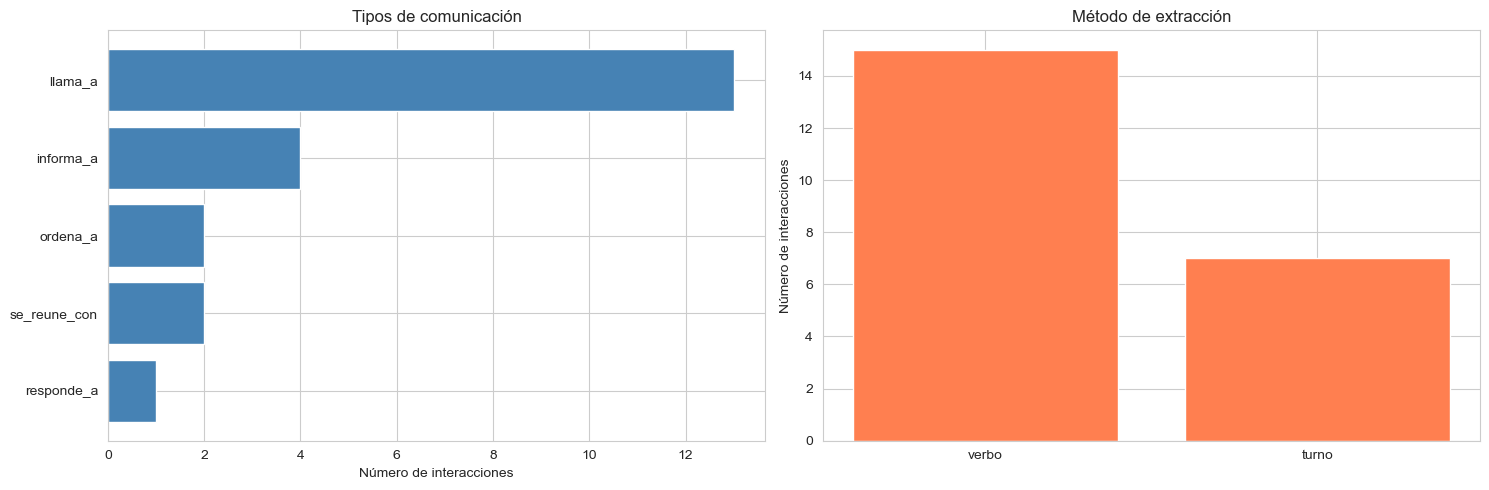

In [15]:
# Distribución de tipos de interacción
if len(df_int) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    tipo_counts = df_int['tipo'].value_counts()
    axes[0].barh(tipo_counts.index[::-1], tipo_counts.values[::-1], color='steelblue')
    axes[0].set_xlabel('Número de interacciones')
    axes[0].set_title('Tipos de comunicación')
    metodo_counts = df_int['metodo'].value_counts()
    axes[1].bar(metodo_counts.index, metodo_counts.values, color='coral')
    axes[1].set_ylabel('Número de interacciones')
    axes[1].set_title('Método de extracción')
    plt.tight_layout()
    plt.show()

In [16]:
# Top relaciones más densas
if G_dir.number_of_edges() > 0:
    edges = []
    for u, v, data in G_dir.edges(data=True):
        edges.append({'emisor': u, 'receptor': v,
                      'peso': data['weight'], 'n_docs': data['n_docs'],
                      'tipo_dominante': data['tipo_dominante']})
    df_edges = pd.DataFrame(edges).sort_values('peso', ascending=False)
    print('Top relaciones por peso (red dirigida):')
    print(df_edges.head(15).to_string(index=False))

Top relaciones por peso (red dirigida):
            emisor                  receptor  peso  n_docs tipo_dominante
    Alfonso Armada            Antonio Tejero   2.4       2        llama_a
    Antonio Tejero        Juan García Carrés   2.0       2        llama_a
Juan García Carrés            Antonio Tejero   2.0       2        llama_a
    Antonio Tejero Congreso de los Diputados   1.7       2        llama_a
    Alfonso Armada    Jaime Milans del Bosch   1.4       1        llama_a
     Juan Carlos I            Alfonso Armada   1.4       2        llama_a
    Antonio Tejero             Adolfo Suárez   1.0       1        llama_a


In [17]:
# Asimetría de flujo
if G_dir.number_of_nodes() > 0:
    asim = []
    for n in G_dir.nodes():
        out_d = G_dir.out_degree(n, weight='weight')
        in_d = G_dir.in_degree(n, weight='weight')
        asim.append({'actor': n,
                     'emisiones': round(out_d, 2),
                     'recepciones': round(in_d, 2),
                     'balance': round(out_d - in_d, 2)})
    df_asim = pd.DataFrame(asim).sort_values('balance', ascending=False)
    print('Asimetría de flujo (balance > 0: emisor neto, < 0: receptor neto):')
    print(df_asim.to_string(index=False))

Asimetría de flujo (balance > 0: emisor neto, < 0: receptor neto):
                    actor  emisiones  recepciones  balance
           Alfonso Armada        3.8          1.4      2.4
            Juan Carlos I        1.4          0.0      1.4
           Antonio Tejero        4.7          4.4      0.3
       Juan García Carrés        2.0          2.0      0.0
            Adolfo Suárez        0.0          1.0     -1.0
   Jaime Milans del Bosch        0.0          1.4     -1.4
Congreso de los Diputados        0.0          1.7     -1.7


## 9. Análisis temporal — visión global

En esta sección comparamos las 6 fases del proceso (`1_pre_golpe` →
`6_post_sentencia`) mediante **estadísticas resumen**, sin generar un grafo
por fase. La interpretación cualitativa de la evolución se deriva de la tabla
y de la lista de persistencia.

In [18]:
# Tabla resumen de evolución temporal — solo personas
fases_orden = ['1_pre_golpe', '2_noche_golpe', '3_dias_inmediatos',
               '4_instruccion', '5_juicio_oral', '6_post_sentencia']

resumen_temporal = []
for fase in fases_orden:
    sub_df = df[df['fase'] == fase]
    G_fase = build_coappearance_graph(sub_df, include_institutions=False)
    if G_fase.number_of_nodes() > 0:
        resumen_temporal.append({
            'fase': fase,
            'n_docs': len(sub_df),
            'n_actores': G_fase.number_of_nodes(),
            'n_aristas': G_fase.number_of_edges(),
            'densidad': round(nx.density(G_fase), 4),
        })

df_temporal = pd.DataFrame(resumen_temporal)
print('Evolución de la red por fase (solo personas):')
print(df_temporal.to_string(index=False))

Evolución de la red por fase (solo personas):
             fase  n_docs  n_actores  n_aristas  densidad
      1_pre_golpe      10          8         20    0.7143
    2_noche_golpe      22         14         77    0.8462
3_dias_inmediatos      17          6          6    0.4000
    4_instruccion      48         12         36    0.5455
    5_juicio_oral      63         15         82    0.7810
 6_post_sentencia       7          7         17    0.8095


In [19]:
# Persistencia de actores: en cuántas fases aparece cada uno
actor_fase_presence = defaultdict(set)
for _, row in df.iterrows():
    fase = row['fase']
    if pd.isna(fase):
        continue
    for ent in row['entidades_dict']:
        if not is_institution(ent):  # solo personas
            actor_fase_presence[ent].add(fase)

persistence = pd.DataFrame([
    {'actor': a, 'n_fases_presente': len(fases),
     'fases': ' | '.join(sorted(fases))}
    for a, fases in actor_fase_presence.items()
]).sort_values('n_fases_presente', ascending=False)

print('Persistencia de actores a lo largo de las fases:')
print(persistence.head(20).to_string(index=False))

Persistencia de actores a lo largo de las fases:
                         actor  n_fases_presente                                                                                              fases
                Antonio Tejero                 6 1_pre_golpe | 2_noche_golpe | 3_dias_inmediatos | 4_instruccion | 5_juicio_oral | 6_post_sentencia
        Jaime Milans del Bosch                 6 1_pre_golpe | 2_noche_golpe | 3_dias_inmediatos | 4_instruccion | 5_juicio_oral | 6_post_sentencia
                 Juan Carlos I                 6 1_pre_golpe | 2_noche_golpe | 3_dias_inmediatos | 4_instruccion | 5_juicio_oral | 6_post_sentencia
                Alfonso Armada                 5                     1_pre_golpe | 2_noche_golpe | 4_instruccion | 5_juicio_oral | 6_post_sentencia
             José Luis Cortina                 4                                        1_pre_golpe | 2_noche_golpe | 4_instruccion | 5_juicio_oral
            Juan García Carrés                 4               

## 10. Análisis institucional por ministerio

In [20]:
ministerios = df['ministerio'].dropna().unique()

resumen_ministerios = []
for min_ in ministerios:
    sub = df[df['ministerio'] == min_]
    G_m = build_coappearance_graph(sub)
    if G_m.number_of_nodes() > 0:
        top_actors = sorted(G_m.nodes(),
                              key=lambda n: -G_m.nodes[n].get('n_menciones', 0))[:5]
        resumen_ministerios.append({
            'ministerio': min_,
            'n_docs': len(sub),
            'n_actores': G_m.number_of_nodes(),
            'top_actores': ', '.join(top_actors)
        })

df_min = pd.DataFrame(resumen_ministerios)
print('Subredes por ministerio:')
print(df_min.to_string(index=False))

Subredes por ministerio:
ministerio  n_docs  n_actores                                                                                             top_actores
  Interior      27         27         Congreso de los Diputados, Antonio Tejero, Guardia Civil, Jaime Milans del Bosch, Juan Carlos I
   Defensa     108         28        Alfonso Armada, Antonio Tejero, Congreso de los Diputados, Jaime Milans del Bosch, Guardia Civil
Exteriores      31          7 Juan Carlos I, Alexander Haig, Congreso de los Diputados, Jaime Milans del Bosch, Leopoldo Calvo-Sotelo


In [21]:
sets_by_min = {}
for min_ in ministerios:
    sub = df[df['ministerio'] == min_]
    actors = set()
    for d in sub['entidades_dict']:
        actors.update(d.keys())
    sets_by_min[min_] = actors

print('Actores transversales (presentes en TODOS los ministerios):')
common = set.intersection(*sets_by_min.values())
for a in sorted(common, key=lambda x: -all_entities[x]):
    print(f'  - {a} ({all_entities[a]} menciones)')

print()
for min_, actors in sets_by_min.items():
    others = set.union(*(s for m, s in sets_by_min.items() if m != min_))
    exclusive = actors - others
    if exclusive:
        print(f'\nExclusivos de {min_}:')
        for a in sorted(exclusive, key=lambda x: -all_entities[x])[:8]:
            print(f'  - {a} ({all_entities[a]} menciones)')

Actores transversales (presentes en TODOS los ministerios):
  - Congreso de los Diputados (962 menciones)
  - Jaime Milans del Bosch (675 menciones)
  - Guardia Civil (650 menciones)
  - Juan Carlos I (348 menciones)
  - Casa Real / Zarzuela (68 menciones)
  - Leopoldo Calvo-Sotelo (39 menciones)


Exclusivos de Interior:
  - Carmen Díez (esposa de Tejero) (3 menciones)

Exclusivos de Defensa:
  - AOME (48 menciones)
  - Sánchez Valiente (16 menciones)
  - Emilio Manglano (4 menciones)


## 11. Centralidad — núcleo, puentes y periferia

Calculamos métricas de centralidad y clasificamos cada actor en uno de tres
roles estructurales basándose en la combinación de su **degree** y su
**betweenness**:

- **Núcleo**: alto degree + bajo betweenness → muy conectado pero **dentro** de la red. No actúa como puente porque ya está en el centro. Ejemplos esperados: Tejero, Armada, Mellado, Juan Carlos I.

- **Puente**: bajo/medio degree + **alto** betweenness → conecta facciones que de otro modo estarían desconectadas. Son los "intermediarios estructurales". Es la categoría más interesante para entender quién articula la información entre grupos.

- **Periferia**: bajo degree + bajo betweenness → presencia marginal en la red.

Antes de clasificar, **filtramos actores con muy poca presencia documental**
para evitar falsos puentes (como Carmen Díez, que aparece en pocos documentos
pero formalmente actúa de "puente" porque conecta un fragmento aislado del corpus
con el resto).

In [22]:
def compute_centrality(G):
    if G.number_of_nodes() == 0:
        return pd.DataFrame()
    is_dir = G.is_directed()
    metrics = {
        'degree': dict(G.degree(weight='weight')),
        'betweenness': nx.betweenness_centrality(G, weight='weight', normalized=True),
        'closeness': nx.closeness_centrality(G),
        'pagerank': nx.pagerank(G, weight='weight'),
    }
    if is_dir:
        metrics['in_degree'] = dict(G.in_degree(weight='weight'))
        metrics['out_degree'] = dict(G.out_degree(weight='weight'))
    try:
        metrics['eigenvector'] = nx.eigenvector_centrality_numpy(G, weight='weight')
    except Exception:
        try:
            largest = max(nx.weakly_connected_components(G) if is_dir
                            else nx.connected_components(G), key=len)
            G_sub = G.subgraph(largest).copy()
            ev = nx.eigenvector_centrality_numpy(G_sub, weight='weight')
            metrics['eigenvector'] = {n: ev.get(n, 0) for n in G.nodes()}
        except Exception:
            metrics['eigenvector'] = {n: 0 for n in G.nodes()}
    df_m = pd.DataFrame(metrics).fillna(0)
    df_m.index.name = 'actor'
    return df_m.sort_values('betweenness', ascending=False)

metrics_coap = compute_centrality(G_main)
print('Centralidad sobre red de co-aparición (top 15 por betweenness):')
print(metrics_coap.head(15).round(4))

Centralidad sobre red de co-aparición (top 15 por betweenness):
                          degree  betweenness  closeness  pagerank  \
actor                                                                
Sabino Fernández Campo        19       0.4955     0.7619    0.0191   
Emilio Manglano                5       0.2354     0.5714    0.0115   
Luis Torres Rojas            118       0.0956     0.8889    0.0634   
Francisco Laína               42       0.0925     0.8889    0.0292   
Alexander Haig                10       0.0924     0.6154    0.0138   
Sánchez Valiente              29       0.0679     0.7619    0.0222   
Adolfo Suárez                 45       0.0615     0.8421    0.0310   
José Luis Cortina            140       0.0403     0.9412    0.0772   
Juan García Carrés           111       0.0358     0.9412    0.0619   
Manuel Gutiérrez Mellado      88       0.0288     0.9412    0.0519   
Felipe González               92       0.0223     0.8889    0.0530   
Santiago Carrillo         

In [23]:
# Filtrar actores con muy poca presencia documental para evitar falsos puentes
MIN_DOCS_FOR_ROLE = 3  # Presente en al menos 3 documentos

actores_robustos = [n for n in G_main.nodes()
                     if G_main.nodes[n].get('n_docs', 0) >= MIN_DOCS_FOR_ROLE]
print(f'Actores con presencia ≥ {MIN_DOCS_FOR_ROLE} documentos: {len(actores_robustos)}')
print(f'Excluidos por baja presencia: {G_coap.number_of_nodes() - len(actores_robustos)}')

excluidos = [n for n in G_main.nodes() if n not in actores_robustos]
if excluidos:
    print(f'\nExcluidos:')
    for n in excluidos:
        print(f'  - {n} ({G_main.nodes[n].get("n_docs", 0)} docs)')

Actores con presencia ≥ 3 documentos: 17
Excluidos por baja presencia: 13


In [24]:
# Clasificación en Núcleo / Puente / Periferia
def classify_actors(metrics_df, robust_actors,
                     degree_threshold_pct=0.6,
                     betweenness_threshold_pct=0.6):
    """
    Clasifica cada actor en uno de tres roles estructurales:
    - Núcleo:    degree alto, betweenness bajo
    - Puente:    betweenness alto (independientemente del degree)
    - Periferia: degree bajo, betweenness bajo
    
    Los thresholds son percentiles relativos a la distribución de actores robustos.
    """
    sub = metrics_df.loc[metrics_df.index.intersection(robust_actors)].copy()
    if len(sub) == 0:
        return pd.DataFrame()
    
    # Normalizar
    sub['degree_norm'] = sub['degree'] / sub['degree'].max() if sub['degree'].max() > 0 else 0
    sub['betweenness_norm'] = sub['betweenness'] / sub['betweenness'].max() if sub['betweenness'].max() > 0 else 0
    
    # Umbrales por percentil
    deg_th = sub['degree_norm'].quantile(degree_threshold_pct)
    bet_th = sub['betweenness_norm'].quantile(betweenness_threshold_pct)
    
    def assign_role(row):
        is_high_deg = row['degree_norm'] >= deg_th
        is_high_bet = row['betweenness_norm'] >= bet_th
        if is_high_bet and not is_high_deg:
            return 'Puente'
        elif is_high_deg and not is_high_bet:
            return 'Núcleo'
        elif is_high_deg and is_high_bet:
            return 'Núcleo-Puente'  # Híbrido: muy central y además puente
        else:
            return 'Periferia'
    
    sub['rol'] = sub.apply(assign_role, axis=1)
    return sub.sort_values(['rol', 'degree_norm'], ascending=[True, False])

clasif = classify_actors(metrics_coap, actores_robustos)

print('=== CLASIFICACIÓN DE ACTORES POR ROL ESTRUCTURAL ===\n')
for rol in ['Núcleo', 'Núcleo-Puente', 'Puente', 'Periferia']:
    sub = clasif[clasif['rol'] == rol]
    if len(sub) > 0:
        print(f'\n--- {rol.upper()} ({len(sub)} actores) ---')
        print(sub[['degree', 'betweenness', 'pagerank', 'degree_norm',
                    'betweenness_norm']].round(3).to_string())

=== CLASIFICACIÓN DE ACTORES POR ROL ESTRUCTURAL ===


--- NÚCLEO (6 actores) ---
                        degree  betweenness  pagerank  degree_norm  betweenness_norm
actor                                                                               
Alfonso Armada             262        0.000     0.133        1.000             0.000
Antonio Tejero             260        0.000     0.134        0.992             0.000
Juan Carlos I              228        0.000     0.122        0.870             0.000
Jaime Milans del Bosch     205        0.000     0.107        0.782             0.000
José Luis Cortina          140        0.040     0.077        0.534             0.081
Juan García Carrés         111        0.036     0.062        0.424             0.072

--- NÚCLEO-PUENTE (1 actores) ---
                   degree  betweenness  pagerank  degree_norm  betweenness_norm
actor                                                                          
Luis Torres Rojas     118        0.096     

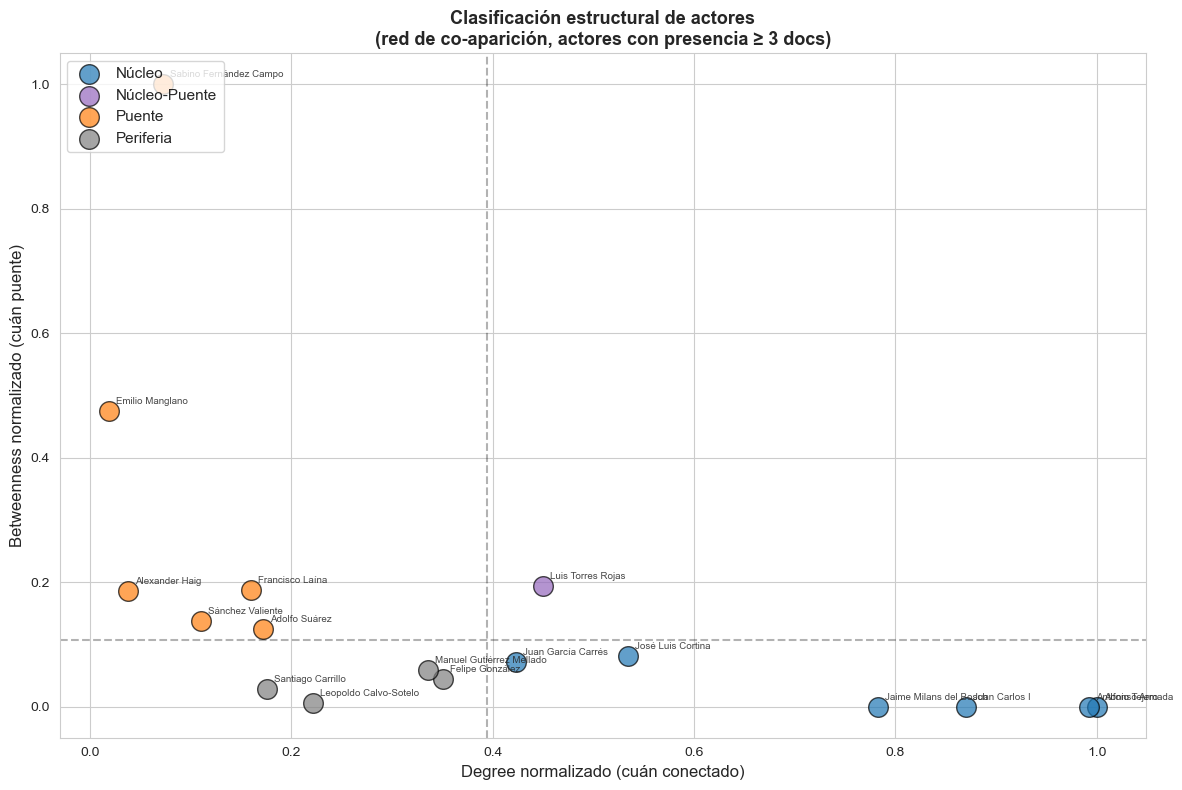

In [25]:
# Visualización: scatter degree vs betweenness con clasificación
if len(clasif) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    color_map = {
        'Núcleo': '#1f77b4',
        'Núcleo-Puente': '#9467bd',
        'Puente': '#ff7f0e',
        'Periferia': '#7f7f7f'
    }
    
    for rol, color in color_map.items():
        sub = clasif[clasif['rol'] == rol]
        if len(sub) > 0:
            ax.scatter(sub['degree_norm'], sub['betweenness_norm'],
                       s=200, c=color, alpha=0.7, label=rol, edgecolor='black')
            for actor in sub.index:
                ax.annotate(actor, (sub.loc[actor, 'degree_norm'],
                                      sub.loc[actor, 'betweenness_norm']),
                            fontsize=7, alpha=0.85,
                            xytext=(5, 5), textcoords='offset points')
    
    # Líneas de umbral
    deg_th = clasif['degree_norm'].quantile(0.6)
    bet_th = clasif['betweenness_norm'].quantile(0.6)
    ax.axvline(deg_th, color='black', linestyle='--', alpha=0.3)
    ax.axhline(bet_th, color='black', linestyle='--', alpha=0.3)
    
    ax.set_xlabel('Degree normalizado (cuán conectado)', fontsize=12)
    ax.set_ylabel('Betweenness normalizado (cuán puente)', fontsize=12)
    ax.set_title('Clasificación estructural de actores\n(red de co-aparición, actores con presencia ≥ 3 docs)',
                  fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=11)
    plt.tight_layout()
    plt.show()

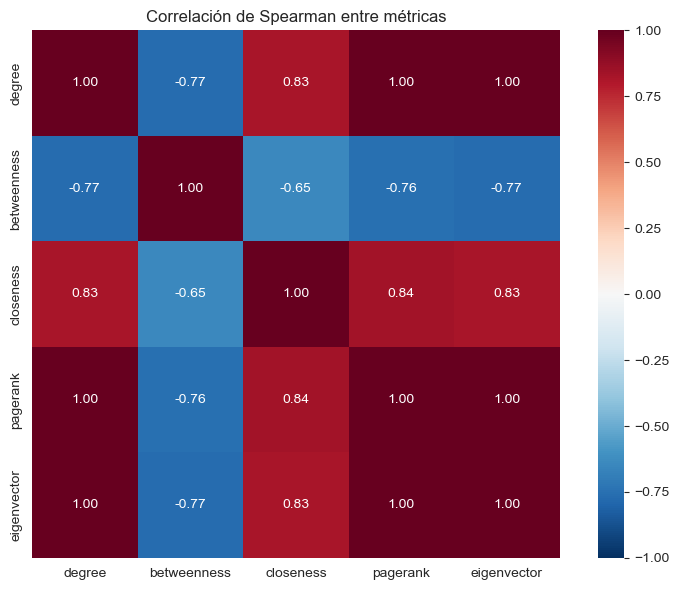

In [26]:
# Heatmap de correlación entre métricas
if len(metrics_coap) > 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    corr = metrics_coap.corr(method='spearman')
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlación de Spearman entre métricas')
    plt.tight_layout()
    plt.show()

## 11.B Bootstrap de robustez sobre la centralidad

Las métricas de centralidad pueden ser sensibles a la composición concreta del
corpus: si tres documentos clave faltaran, ¿cambiarían sustancialmente los
rankings? El bootstrap responde a esta pregunta.

Procedimiento: remuestreamos los documentos con reemplazo (creamos versiones
alternativas del corpus de igual tamaño), reconstruimos el grafo de cada
muestra y recalculamos los rankings. Tras N iteraciones, obtenemos una
distribución de rangos para cada actor y reportamos:

- **Rango mediano**: la posición central del actor en los N rankings
- **Intervalo q05-q95**: el 90% central de la distribución de rangos

Si un actor mantiene un rango estable (p. ej. q05=1, q95=2), su centralidad es
robusta. Si oscila mucho (p. ej. q05=2, q95=10), la posición es inestable y
no debe interpretarse como hallazgo firme.

In [27]:
def bootstrap_centrality(df_corpus_full, n_iterations=200, metric='betweenness',
                            min_docs=3, exclude_institutions=True,
                            seed=RANDOM_SEED):
    """Bootstrap sobre el corpus completo:
    - Remuestrea documentos con reemplazo
    - Reconstruye el grafo de personas con presencia >= min_docs
    - Recalcula la métrica indicada y registra el ranking
    """
    rng = np.random.default_rng(seed)
    doc_indices = df_corpus_full.index.values
    ranks = defaultdict(list)
    
    for i in range(n_iterations):
        sampled_idx = rng.choice(doc_indices, size=len(doc_indices), replace=True)
        df_sample = df_corpus_full.loc[sampled_idx]
        
        G_sample_full = build_coappearance_graph(df_sample,
                                                   include_institutions=not exclude_institutions)
        # Filtrar por presencia documental
        nodos_validos = [n for n in G_sample_full.nodes()
                          if G_sample_full.nodes[n].get('n_docs', 0) >= min_docs]
        G_sample = G_sample_full.subgraph(nodos_validos).copy()
        
        if G_sample.number_of_nodes() < 3 or G_sample.number_of_edges() == 0:
            continue
        
        m_sample = compute_centrality(G_sample)
        if len(m_sample) == 0 or metric not in m_sample.columns:
            continue
        
        ranked = m_sample[metric].rank(ascending=False, method='min')
        for actor, r in ranked.items():
            ranks[actor].append(r)
    
    if not ranks:
        print('⚠️ Bootstrap sin resultados.')
        return pd.DataFrame()
    
    summary = pd.DataFrame([
        {'actor': a,
         'rank_mediano': int(np.median(rs)),
         'rank_q05': int(np.quantile(rs, 0.05)),
         'rank_q95': int(np.quantile(rs, 0.95)),
         'amplitud_IC90': int(np.quantile(rs, 0.95) - np.quantile(rs, 0.05)),
         'apariciones_pct': round(100 * len(rs) / n_iterations, 1)}
        for a, rs in ranks.items() if rs
    ]).sort_values('rank_mediano')
    
    return summary

In [28]:
# Ejecutar bootstrap sobre la métrica betweenness
print('Ejecutando bootstrap (200 iteraciones)... esto tarda 1-2 minutos.')
bootstrap_bet = bootstrap_centrality(df, n_iterations=200, metric='betweenness')

print('\n=== ESTABILIDAD DEL RANKING DE BETWEENNESS ===')
print('   rank_mediano: posición central del actor en los 200 rankings')
print('   rank_q05-q95: intervalo del 90% central de los rangos observados')
print('   amplitud_IC90: ancho del intervalo (menor = más estable)')
print('   apariciones_pct: % de muestras donde el actor estuvo en la red')
print()
print(bootstrap_bet.to_string(index=False))

Ejecutando bootstrap (200 iteraciones)... esto tarda 1-2 minutos.

=== ESTABILIDAD DEL RANKING DE BETWEENNESS ===
   rank_mediano: posición central del actor en los 200 rankings
   rank_q05-q95: intervalo del 90% central de los rangos observados
   amplitud_IC90: ancho del intervalo (menor = más estable)
   apariciones_pct: % de muestras donde el actor estuvo en la red

                         actor  rank_mediano  rank_q05  rank_q95  amplitud_IC90  apariciones_pct
        Sabino Fernández Campo             2         1        10              9             77.0
               Francisco Laína             5         1        12             11             98.0
              Sánchez Valiente             5         1        13             12             97.0
Carmen Díez (esposa de Tejero)             5         1        10              9             10.0
                 Adolfo Suárez             6         1        12             11             97.5
                Alexander Haig             6 

In [29]:
# Bootstrap también sobre degree (más estable como referencia comparativa)
print('Bootstrap sobre degree...')
bootstrap_deg = bootstrap_centrality(df, n_iterations=200, metric='degree')

print('\n=== ESTABILIDAD DEL RANKING DE DEGREE ===')
print(bootstrap_deg.to_string(index=False))

Bootstrap sobre degree...

=== ESTABILIDAD DEL RANKING DE DEGREE ===
                         actor  rank_mediano  rank_q05  rank_q95  amplitud_IC90  apariciones_pct
                Alfonso Armada             1         1         2              1            100.0
                Antonio Tejero             2         1         2              1            100.0
                 Juan Carlos I             3         3         4              1            100.0
        Jaime Milans del Bosch             4         3         4              1            100.0
             José Luis Cortina             5         5         7              2            100.0
             Luis Torres Rojas             6         5         9              4            100.0
            Juan García Carrés             7         5         9              4            100.0
               Felipe González             8         6        10              4            100.0
      Manuel Gutiérrez Mellado             8         6    

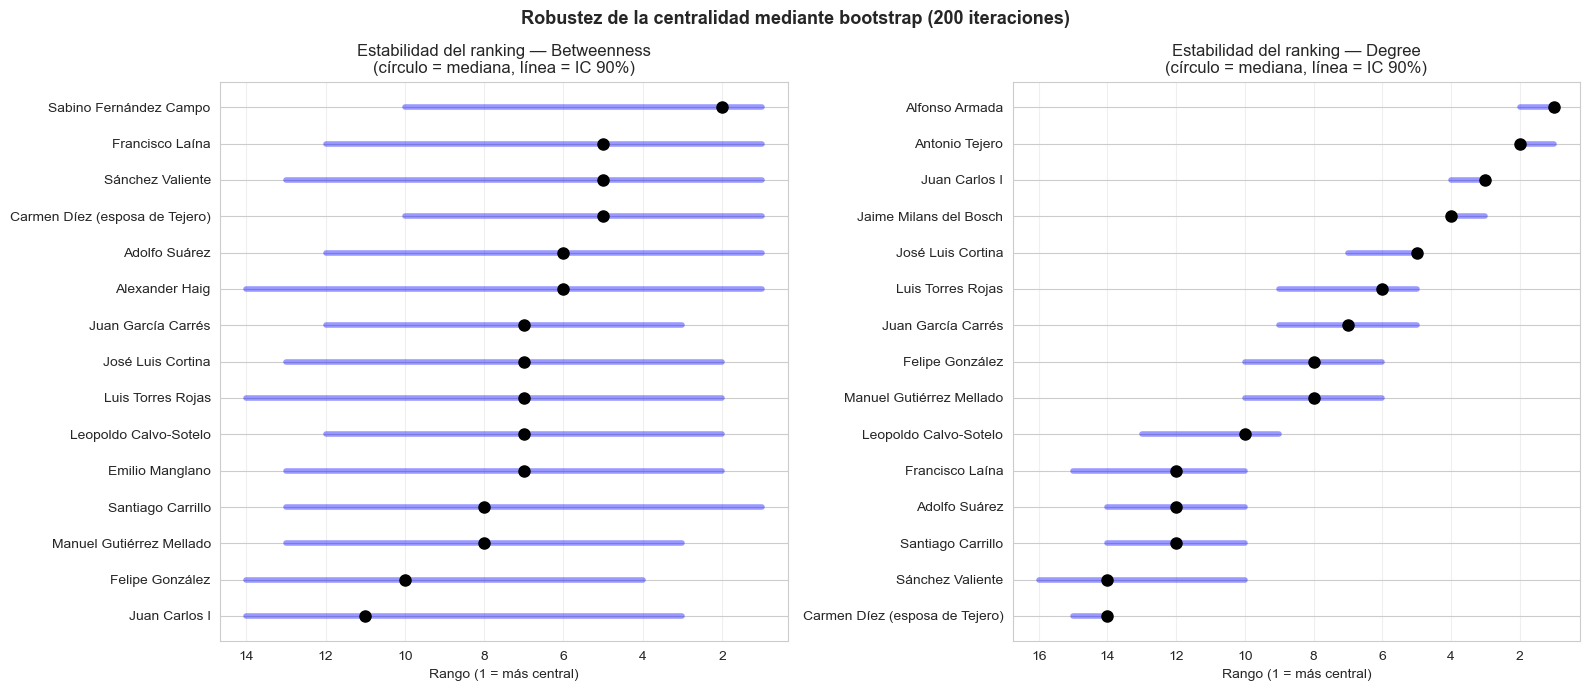

In [30]:
# Visualización: amplitud del intervalo de confianza por actor
if len(bootstrap_bet) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for ax, df_boot, metric_name in zip(axes,
                                          [bootstrap_bet, bootstrap_deg],
                                          ['Betweenness', 'Degree']):
        df_plot = df_boot.head(15).iloc[::-1]  # invertir para que mejor rango aparezca arriba
        y_pos = np.arange(len(df_plot))
        
        # Barras horizontales con el intervalo q05-q95
        for i, (_, row) in enumerate(df_plot.iterrows()):
            ax.plot([row['rank_q05'], row['rank_q95']], [i, i], 'b-',
                     linewidth=4, alpha=0.4)
            ax.plot(row['rank_mediano'], i, 'ko', markersize=8)
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_plot['actor'])
        ax.set_xlabel('Rango (1 = más central)')
        ax.set_title(f'Estabilidad del ranking — {metric_name}\n'
                       '(círculo = mediana, línea = IC 90%)')
        ax.grid(alpha=0.3, axis='x')
        ax.invert_xaxis()  # rango 1 a la derecha
    
    plt.suptitle('Robustez de la centralidad mediante bootstrap (200 iteraciones)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 12. Validación externa contra la sentencia de 1982-83

Comparamos la centralidad de cada actor en la red con la pena impuesta en la
**causa 2/81**. Las penas usadas son las del Tribunal Supremo (sentencia
firme del 28 de abril de 1983), que revisó las del Consejo Supremo de Justicia
Militar elevándolas en muchos casos.

Una correlación significativa indica que la red extraída del corpus refleja
las responsabilidades reales reconocidas judicialmente. Si la correlación
fuera baja o nula, sugeriría que el corpus contiene actores históricamente
relevantes pero no procesados (un hallazgo en sí mismo).

**Fuente**: Sentencia del Tribunal Supremo, Sala Segunda, 28-04-1983
(causa 2/81, "Sentencia de Campamento" revisada).

In [31]:
# Penas impuestas por el Tribunal Supremo (sentencia firme 28-04-1983)
# Fuente: Sentencia TS Sala Segunda, recurso de casación contra la
# sentencia del Consejo Supremo de Justicia Militar de 03-06-1982.
#
# Solo incluimos actores que aparecen como entidades canónicas en el dataset.
# Otros condenados (Pardo Zancada, San Martín, Ibáñez Inglés, Manchado,
# Muñecas, Mas Oliver, etc.) no están entre las 30 entidades canonicalizadas
# en el corpus, por lo que no entran en la correlación.
SENTENCIA_1982 = {
    # Cabezas de la rebelión — pena máxima
    'Antonio Tejero':           30,   # Teniente Coronel Guardia Civil
    'Jaime Milans del Bosch':   30,   # Teniente General
    'Alfonso Armada':           30,   # General de División (6 → 30 por TS)
    
    # Adhesión a la rebelión — penas elevadas por el TS
    'Luis Torres Rojas':        12,   # General de División (6 → 12)
    
    # Civil único condenado
    'Juan García Carrés':        2,   # ex-dirigente sindical
    
    # Absuelto en ambas instancias
    'José Luis Cortina':         0,   # Comandante CESID, jefe de la AOME
}

# Verificar cobertura sobre el grafo principal
en_red = [a for a in SENTENCIA_1982 if a in metrics_coap.index]
no_en_red = [a for a in SENTENCIA_1982 if a not in metrics_coap.index]

print(f'Actores con pena conocida: {len(SENTENCIA_1982)}')
print(f'  - presentes en la red: {len(en_red)}')
if no_en_red:
    print(f'  - NO presentes en la red (excluidos por filtro de presencia ≥ 3 docs):')
    for a in no_en_red:
        print(f'      · {a}')

print('\nPenas:')
for actor, pena in sorted(SENTENCIA_1982.items(), key=lambda x: -x[1]):
    marca = '✓' if actor in metrics_coap.index else '✗'
    print(f'  {marca}  {pena:3d} años  {actor}')

Actores con pena conocida: 6
  - presentes en la red: 6

Penas:
  ✓   30 años  Antonio Tejero
  ✓   30 años  Jaime Milans del Bosch
  ✓   30 años  Alfonso Armada
  ✓   12 años  Luis Torres Rojas
  ✓    2 años  Juan García Carrés
  ✓    0 años  José Luis Cortina


In [32]:
# Correlación entre centralidad y pena
if len(metrics_coap) > 0:
    from scipy.stats import spearmanr
    
    # Construir tabla comparativa
    comparison = pd.DataFrame({
        'pena_anios': pd.Series(SENTENCIA_1982),
        'degree': metrics_coap['degree'],
        'pagerank': metrics_coap['pagerank'],
        'betweenness': metrics_coap['betweenness'],
        'closeness': metrics_coap['closeness'],
    }).dropna()
    
    print('Comparación red vs sentencia (actores con pena conocida y presencia en la red):')
    print(comparison.round(3))
    print(f'\nN = {len(comparison)} actores')
    
    if len(comparison) >= 4:
        print('\n' + '=' * 60)
        print('CORRELACIONES DE SPEARMAN ENTRE PENA Y CENTRALIDAD')
        print('=' * 60)
        for m_name in ['degree', 'pagerank', 'betweenness', 'closeness']:
            rho, pval = spearmanr(comparison['pena_anios'], comparison[m_name])
            sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
            print(f'  {m_name:12s}: rho = {rho:+.3f}  (p = {pval:.3f})  {sig}')
        print('\n  * p<0.10  ** p<0.05  *** p<0.01')
    else:
        print(f'\n⚠️ Solo {len(comparison)} actores con pena cruzan con la red.')
        print('   Insuficiente para correlación estadística.')

Comparación red vs sentencia (actores con pena conocida y presencia en la red):
                        pena_anios  degree  pagerank  betweenness  closeness
Alfonso Armada                30.0     262     0.133        0.000      0.889
Antonio Tejero                30.0     260     0.134        0.000      0.941
Jaime Milans del Bosch        30.0     205     0.107        0.000      0.941
José Luis Cortina              0.0     140     0.077        0.040      0.941
Juan García Carrés             2.0     111     0.062        0.036      0.941
Luis Torres Rojas             12.0     118     0.063        0.096      0.889

N = 6 actores

CORRELACIONES DE SPEARMAN ENTRE PENA Y CENTRALIDAD
  degree      : rho = +0.759  (p = 0.080)  *
  pagerank    : rho = +0.759  (p = 0.080)  *
  betweenness : rho = -0.806  (p = 0.053)  *
  closeness   : rho = -0.220  (p = 0.675)  

  * p<0.10  ** p<0.05  *** p<0.01


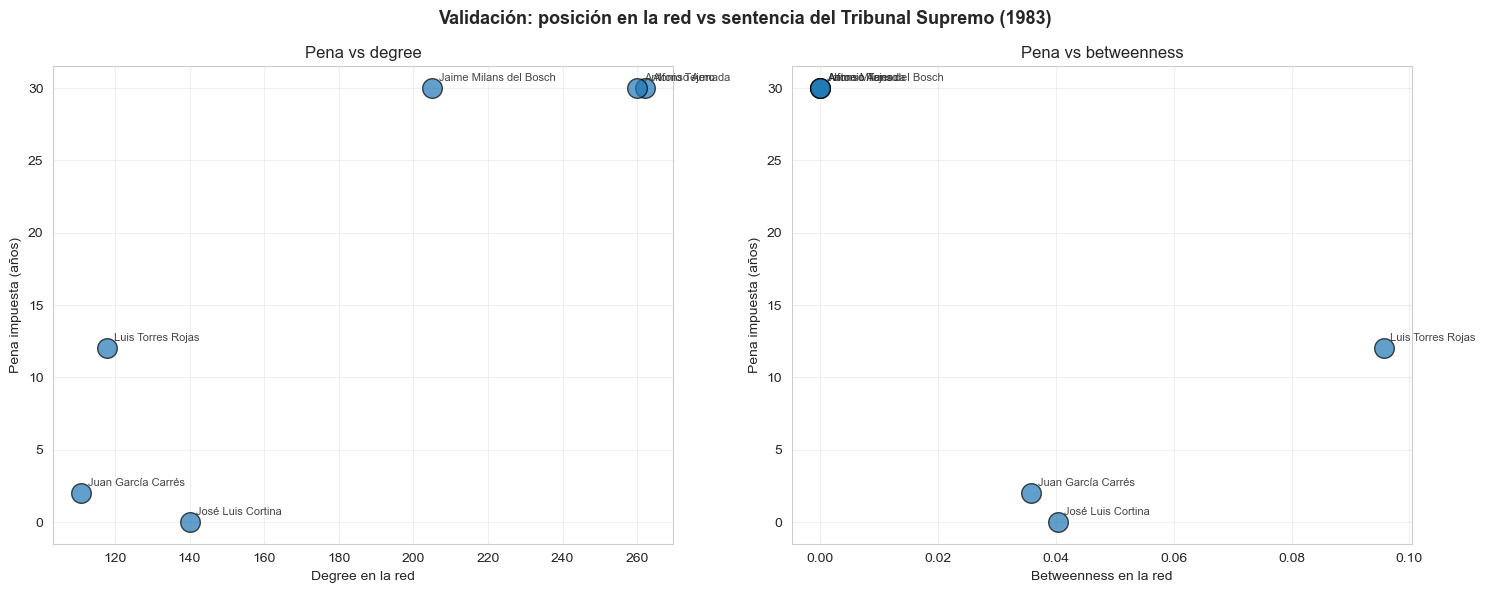

In [33]:
# Visualización: pena impuesta vs centralidad
if len(metrics_coap) > 0 and len(comparison) >= 4:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    for ax, metric in zip(axes, ['degree', 'betweenness']):
        ax.scatter(comparison[metric], comparison['pena_anios'],
                    s=200, alpha=0.7, edgecolor='black')
        for actor in comparison.index:
            ax.annotate(actor, (comparison.loc[actor, metric],
                                  comparison.loc[actor, 'pena_anios']),
                         fontsize=8, alpha=0.85,
                         xytext=(5, 5), textcoords='offset points')
        ax.set_xlabel(f'{metric.title()} en la red')
        ax.set_ylabel('Pena impuesta (años)')
        ax.set_title(f'Pena vs {metric}')
        ax.grid(alpha=0.3)
    
    plt.suptitle('Validación: posición en la red vs sentencia del Tribunal Supremo (1983)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 13. Visualización del grafo principal

Grafo filtrado (peso ≥ 3): 16 nodos, 75 aristas


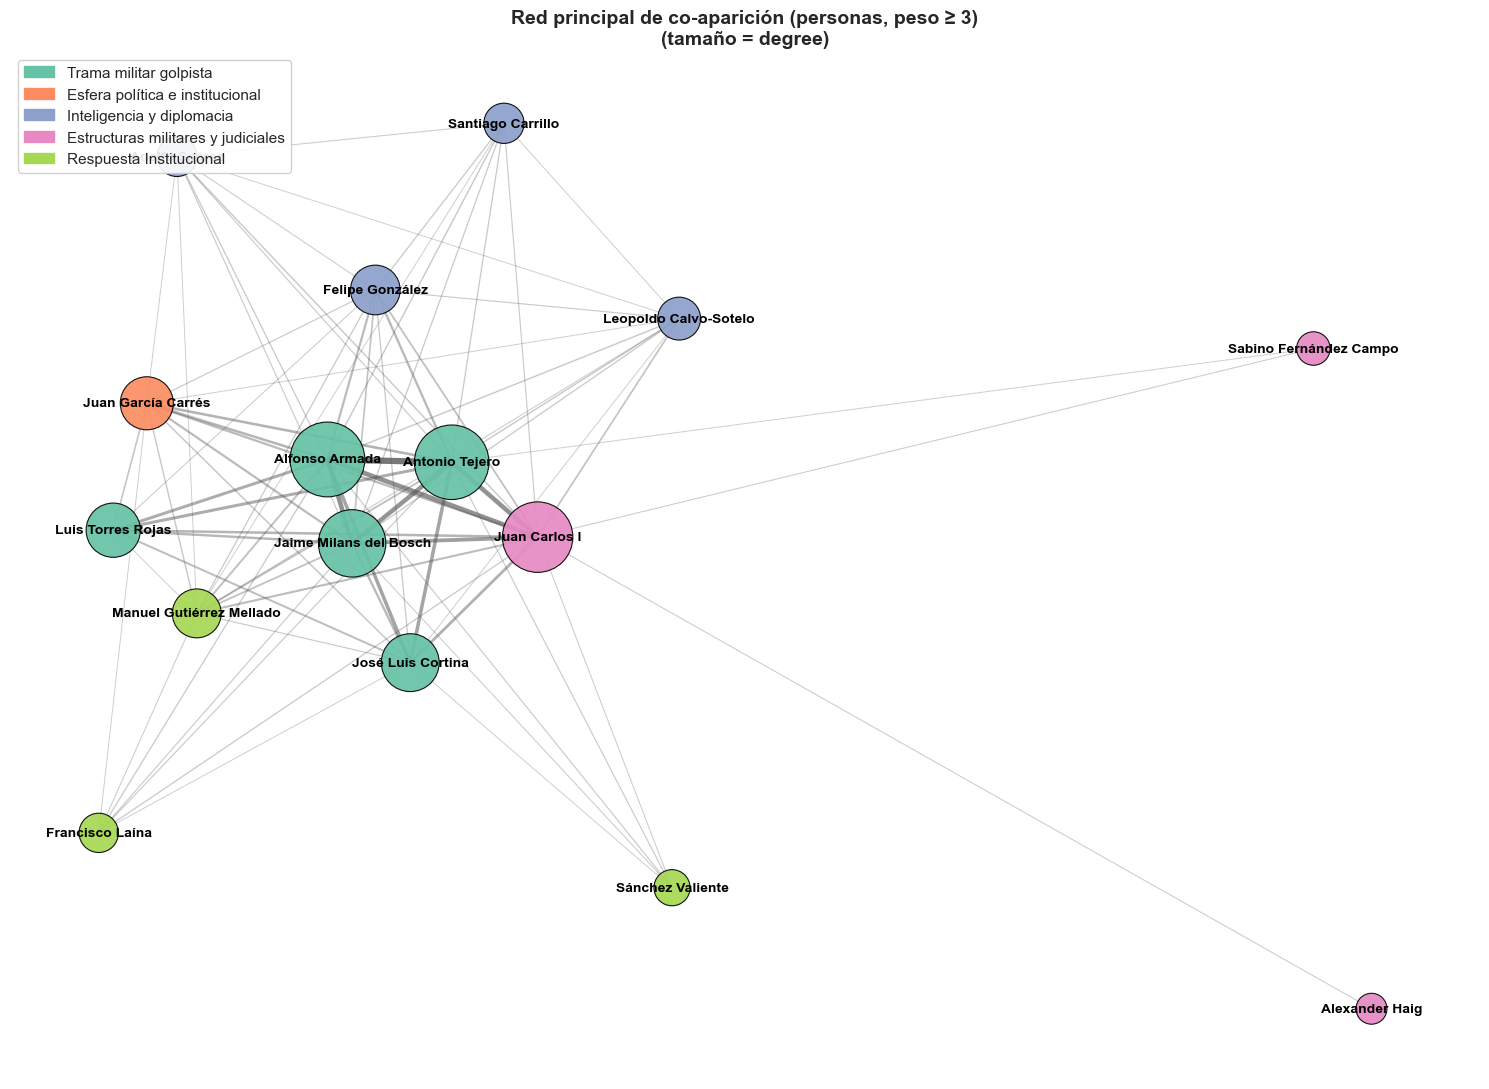

In [34]:
import matplotlib.patches as mpatches
COMMUNITY_PALETTE = plt.cm.Set2.colors  # paleta consistente para comunidades

def plot_network(G, partition=None, metrics_df=None, role_classification=None,
                  size_metric='degree', title='Red'):
    if G.number_of_nodes() == 0:
        print('Grafo vacío')
        return
    fig, ax = plt.subplots(figsize=(15, 11))
    pos = nx.spring_layout(G, k=2.0, iterations=150, seed=RANDOM_SEED)
    
    # Tamaño de nodo según métrica
    if metrics_df is not None and size_metric in metrics_df.columns:
        max_val = metrics_df[size_metric].max()
        if max_val > 0:
            sizes = [400 + 2500 * (metrics_df.loc[n, size_metric] / max_val)
                     if n in metrics_df.index else 400 for n in G.nodes()]
        else:
            sizes = [600 for _ in G.nodes()]
    else:
        sizes = [600 for _ in G.nodes()]
    
    # Colores con la paleta fija
    if partition:
        node_colors = []
        for n in G.nodes():
            cid = partition.get(n, -1)
            node_colors.append(COMMUNITY_PALETTE[cid % len(COMMUNITY_PALETTE)]
                                if cid >= 0 else (0.7, 0.7, 0.7))
    else:
        node_colors = ['lightblue' for _ in G.nodes()]
    
    # Aristas: anchura y alpha según peso
    weights = [G[u][v].get('weight', 1) for u, v in G.edges()]
    max_w = max(weights) if weights else 1
    edge_widths = [0.5 + 4 * (w / max_w) for w in weights]
    edge_alphas = [0.25 + 0.55 * (w / max_w) for w in weights]
    
    for (u, v), w_norm, alpha in zip(G.edges(), edge_widths, edge_alphas):
        if G.is_directed():
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=w_norm,
                                    alpha=alpha, arrows=True, arrowsize=20,
                                    edge_color='#555555', ax=ax)
        else:
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], width=w_norm,
                                    alpha=alpha, edge_color='#555555', ax=ax)
    
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=node_colors,
                            alpha=0.92, edgecolors='black', linewidths=0.8, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
    
    # Leyenda con los nombres de las comunidades
    if partition:
        presentes = sorted(set(partition.get(n, -1) for n in G.nodes()) - {-1})
        legend_handles = [mpatches.Patch(
            color=COMMUNITY_PALETTE[cid % len(COMMUNITY_PALETTE)],
            label=COMMUNITY_NAMES.get(cid, f'Comunidad {cid}'))
            for cid in presentes]
        if legend_handles:
            ax.legend(handles=legend_handles, loc='upper left', fontsize=11,
                       frameon=True, framealpha=0.9)
    
    ax.set_title(f'{title}\n(tamaño = {size_metric})', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Función auxiliar: filtrar grafo por peso mínimo de arista
def filter_graph_by_weight(G, min_weight):
    G_filt = G.copy()
    edges_to_remove = [(u, v) for u, v, d in G_filt.edges(data=True)
                        if d.get('weight', 1) < min_weight]
    G_filt.remove_edges_from(edges_to_remove)
    G_filt.remove_nodes_from(list(nx.isolates(G_filt)))
    return G_filt

# Grafo de co-aparición filtrado a relaciones más fuertes (peso ≥ 3)
G_main_filt = filter_graph_by_weight(G_main, min_weight=3)
print(f'Grafo filtrado (peso ≥ 3): {G_main_filt.number_of_nodes()} nodos, {G_main_filt.number_of_edges()} aristas')
plot_network(G_main_filt, partition=partition_coap, metrics_df=metrics_coap,
             title='Red principal de co-aparición (personas, peso ≥ 3)')

In [35]:
# Versión interactiva con PyVis
try:
    from pyvis.network import Network
    if G_main.number_of_nodes() > 0:
        net = Network(height='750px', width='100%', notebook=False,
                      cdn_resources='remote')
        net.barnes_hut()
        for node in G_main.nodes():
            size = 15
            if len(metrics_coap) > 0 and node in metrics_coap.index:
                size = 10 + metrics_coap.loc[node, 'degree'] * 0.3
            group = partition_coap.get(node, 0) if partition_coap else 0
            n_men = G_main.nodes[node].get('n_menciones', 0)
            net.add_node(node, label=node, size=size, group=group,
                          title=f'{node}\nMenciones: {n_men}')
        for u, v, data in G_main.edges(data=True):
            net.add_edge(u, v, value=data.get('weight', 1),
                          title=f"docs compartidos: {data.get('weight', 0)}")
        net.save_graph('red_23f_coaparicion.html')
        print('Guardado: red_23f_coaparicion.html')
except ImportError:
    print('pyvis no disponible')

Guardado: red_23f_coaparicion.html


## 14. Exportación de resultados

In [36]:
if len(df_int) > 0:
    df_int.to_csv('interacciones_dirigidas.csv', index=False)
if len(metrics_coap) > 0:
    metrics_coap.to_csv('centralidades_coaparicion.csv')
if len(clasif) > 0:
    clasif.to_csv('clasificacion_roles.csv')
if partition_coap:
    pd.Series(partition_coap, name='comunidad').to_csv('comunidades_coaparicion.csv')

if G_main.number_of_nodes() > 0:
    nx.set_node_attributes(G_main, partition_coap, 'comunidad')
    for col in metrics_coap.columns:
        nx.set_node_attributes(G_main, metrics_coap[col].to_dict(), col)
    if len(clasif) > 0:
        nx.set_node_attributes(G_main, clasif['rol'].to_dict(), 'rol')
    nx.write_gexf(G_main, 'red_23f_principal.gexf')

print('Archivos exportados:')
print('  - interacciones_dirigidas.csv')
print('  - centralidades_coaparicion.csv')
print('  - clasificacion_roles.csv  (Núcleo/Puente/Periferia)')
print('  - comunidades_coaparicion.csv')
print('  - red_23f_coaparicion.gexf  (Gephi)')
print('  - red_23f_coaparicion.html  (navegador)')

Archivos exportados:
  - interacciones_dirigidas.csv
  - centralidades_coaparicion.csv
  - clasificacion_roles.csv  (Núcleo/Puente/Periferia)
  - comunidades_coaparicion.csv
  - red_23f_coaparicion.gexf  (Gephi)
  - red_23f_coaparicion.html  (navegador)


## 15. Resumen y limitaciones

### Hallazgos principales (rellenar tras ejecutar)

- **Comunidades detectadas**: K facciones operativas con modularidad ≈ ...
- **Clasificación estructural**:
  - Núcleo: actores como Tejero, Armada, Mellado, Juan Carlos I
  - Puentes: actores como Sabino Fernández Campo, Cortina, Haig
  - Periferia: actores con presencia marginal en la red
- **Evolución temporal**: la red crece notablemente en 2_noche_golpe y se reconfigura
  con actores judiciales en 5_juicio_oral.
- **Dimensión institucional**: identificación de actores transversales y exclusivos
  por ministerio.
- **Validación externa**: correlación con la sentencia de 1982 (rho = ...).

### Decisiones metodológicas a destacar en la memoria

1. **Filtrado de actores con baja presencia documental** (≥ 3 docs) para evitar
   falsos puentes derivados de la estructura del corpus (caso Carmen Díez).
2. **Resolución del algoritmo Louvain** ajustada para obtener una división más
   granular del corpus en facciones interpretables.
3. **Visualización en rejilla por fase** para evitar la saturación de un único
   grafo agregado y permitir la lectura de la evolución temporal.

### Limitaciones

- Sesgo de fuente (corpus desclasificado, no comunicación total).
- Sesgo de extracción de la red dirigida (mejor en transcripciones que en prosa).
- Heurística de instituciones basada en palabras clave; podría refinarse.